In [3]:
###Load & Inspect 

In [4]:
import pandas as pd

df = pd.read_csv("house_prices.csv")

In [5]:
df.shape

(187531, 21)

In [6]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [8]:
df.describe() 

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [9]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [10]:
'''### Inspection Summary

The dataset contains **187,531 rows and 21 columns**.
- The numeric columns are **Index, Price (in rupees), Dimensions, and Plot Area**.
- The remaining **17 columns are text/string columns**.
- **Dimensions** and **Plot Area** have the highest percentage of missing values, with **100% missing values**.
- Other columns with high missing values include **Society (58.49%)**, **Super Area (57.42%)**, **Car Parking (55.11%)**, **overlooking (43.43%)**, and **Carpet Area (43.02%)**.
- The target column, **Price (in rupees)**, has approximately **9.42% missing values**.
'''

'### Inspection Summary\n\nThe dataset contains **187,531 rows and 21 columns**.\n- The numeric columns are **Index, Price (in rupees), Dimensions, and Plot Area**.\n- The remaining **17 columns are text/string columns**.\n- **Dimensions** and **Plot Area** have the highest percentage of missing values, with **100% missing values**.\n- Other columns with high missing values include **Society (58.49%)**, **Super Area (57.42%)**, **Car Parking (55.11%)**, **overlooking (43.43%)**, and **Carpet Area (43.02%)**.\n- The target column, **Price (in rupees)**, has approximately **9.42% missing values**.\n'

In [11]:
###Exploratory Data Analysis (EDA)

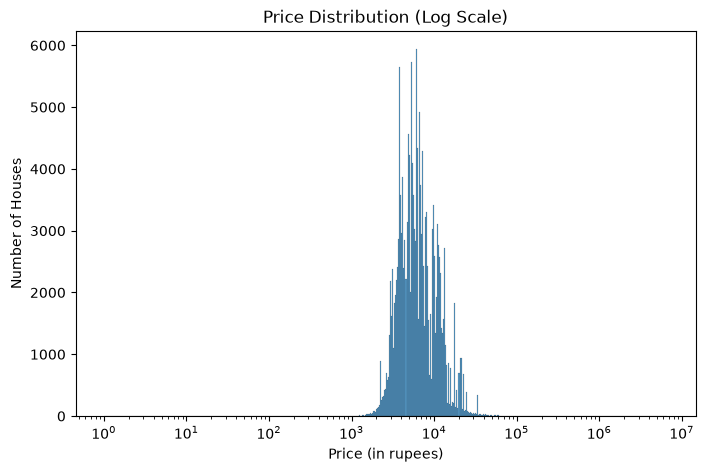

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Price (in rupees)"].dropna(),
    log_scale=True
)

plt.title("Price Distribution (Log Scale)")
plt.xlabel("Price (in rupees)")
plt.ylabel("Number of Houses")

plt.show()

In [13]:
##**Comment:** Most house prices are concentrated in a lower price range, while fewer properties have very high prices. The price distribution is skewed, so using a log scale makes the distribution easier to understand.

In [14]:
# Extract the numeric value from Carpet Area for visualization
df["carpet_area_eda"] = (
    df["Carpet Area"]
    .str.extract(r"([\d,.]+)")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)

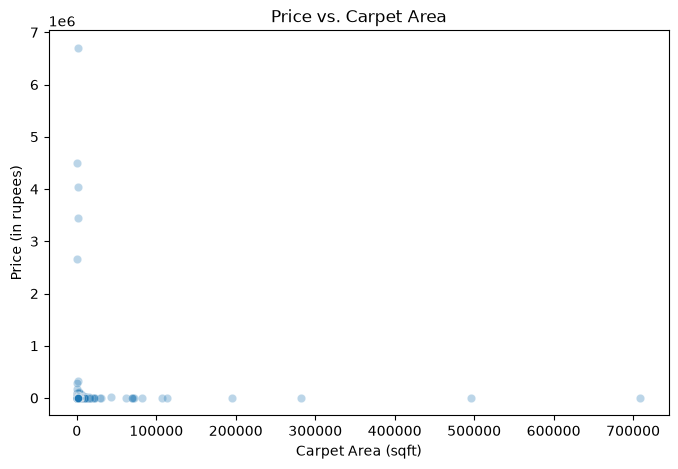

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="carpet_area_eda",
    y="Price (in rupees)",
    alpha=0.3
)

plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (in rupees)")

plt.show()

In [16]:
'''Comment: The scatter plot is affected by some extreme values in carpet area, which makes most of the data points appear concentrated near the lower values. However, the plot still suggests that property price may generally increase as carpet area increases. The extreme values will be handled later during the cleaning stage.
'''

'Comment: The scatter plot is affected by some extreme values in carpet area, which makes most of the data points appear concentrated near the lower values. However, the plot still suggests that property price may generally increase as carpet area increases. The extreme values will be handled later during the cleaning stage.\n'

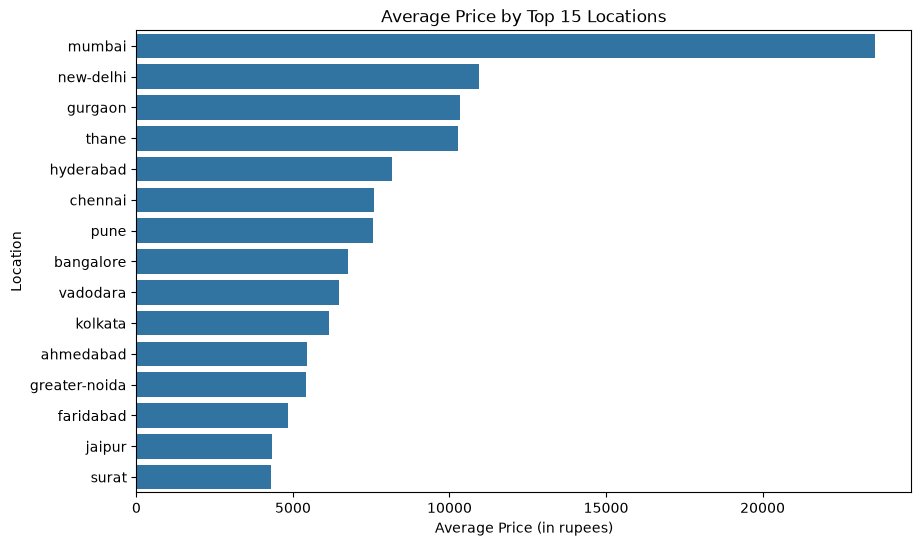

In [17]:
# Get the top 15 most common locations
top_15_locations = df["location"].value_counts().head(15).index

# Calculate the average price for each location
avg_price_by_location = (
    df[df["location"].isin(top_15_locations)]
    .groupby("location")["Price (in rupees)"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_price_by_location.values,
    y=avg_price_by_location.index
)

plt.title("Average Price by Top 15 Locations")
plt.xlabel("Average Price (in rupees)")
plt.ylabel("Location")

plt.show()

In [18]:
'''**Comment:** The average house price varies between different locations. Mumbai has the highest average price among the top 15 locations, while Jaipur and Surat have lower average prices. This shows that location can have a strong effect on house prices.
'''

'**Comment:** The average house price varies between different locations. Mumbai has the highest average price among the top 15 locations, while Jaipur and Surat have lower average prices. This shows that location can have a strong effect on house prices.\n'

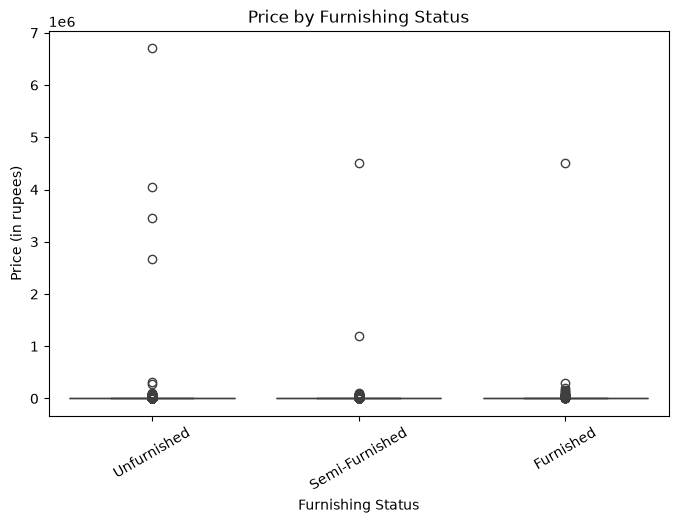

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="Price (in rupees)"
)

plt.title("Price by Furnishing Status")
plt.xlabel("Furnishing Status")
plt.ylabel("Price (in rupees)")

plt.xticks(rotation=30)

plt.show()

In [20]:
'''**Comment:** The box plot shows that house prices vary across different furnishing statuses. However, there are several extreme outliers with very high prices, which makes it difficult to compare the main distribution between the groups. These outliers will be handled later during the cleaning stage.'''

'**Comment:** The box plot shows that house prices vary across different furnishing statuses. However, there are several extreme outliers with very high prices, which makes it difficult to compare the main distribution between the groups. These outliers will be handled later during the cleaning stage.'

In [21]:
## Cleaning & Feature Engineering

In [22]:
### Cleaning the Price Column
def parse_amount(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5

        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7

        return float(x.replace(",", ""))

    except ValueError:
        return None


# Convert the price column to numeric values
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

# Remove rows where the price could not be converted
df = df.dropna(subset=["price_clean"])

df[["Amount(in rupees)", "price_clean"]].head()

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0


In [23]:
### Cleaning Area Columns
import re
import numpy as np


def parse_area(x):
    if not isinstance(x, str):
        return np.nan

    x = x.strip().lower()

    # Extract the numeric value
    match = re.search(r"[\d,.]+", x)

    if not match:
        return np.nan

    value = float(match.group().replace(",", ""))

    # Convert square meters to square feet
    if "sqm" in x or "sq m" in x or "square meter" in x:
        value = value * 10.764

    return value


df["carpet_area_clean"] = df["Carpet Area"].apply(parse_area)

df["super_area_clean"] = df["Super Area"].apply(parse_area)

df[[
    "Carpet Area",
    "carpet_area_clean",
    "Super Area",
    "super_area_clean"
]].head()

,Carpet Area,carpet_area_clean,Super Area,super_area_clean
0,500 sqft,500.0,NaN,NaN
1,473 sqft,473.0,NaN,NaN
2,779 sqft,779.0,NaN,NaN
3,530 sqft,530.0,NaN,NaN
4,635 sqft,635.0,NaN,NaN


In [24]:
df[["Super Area", "super_area_clean"]].dropna().head(10)

,Super Area,super_area_clean
5,680 sqft,680.0
7,575 sqft,575.0
8,600 sqft,600.0
11,1165 sqft,1165.0
12,844 sqft,844.0
14,650 sqft,650.0
17,540 sqft,540.0
19,520 sqft,520.0
25,580 sqft,580.0
27,630 sqft,630.0


In [25]:
### Cleaning the Floor Column
def parse_floor(x):
    if not isinstance(x, str):
        return np.nan

    x = x.strip().lower()

    if "ground" in x:
        return 0

    if "basement" in x:
        return -1

    match = re.search(r"\d+", x)

    if match:
        return float(match.group())

    return np.nan


df["floor_clean"] = df["Floor"].apply(parse_floor)

df[["Floor", "floor_clean"]].head(15)

,Floor,floor_clean
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0
5,2 out of 7,2.0
6,4 out of 5,4.0
7,Ground out of 7,0.0
8,Ground out of 2,0.0
9,3 out of 27,3.0


In [26]:
### Cleaning Bathroom, Balcony, and Car Parking
def extract_number(x):
    if pd.isna(x):
        return np.nan

    match = re.search(r"\d+", str(x))

    if match:
        return float(match.group())

    return np.nan


# Extract numeric values
df["bathroom_clean"] = df["Bathroom"].apply(extract_number)

df["balcony_clean"] = df["Balcony"].apply(extract_number)

df["parking_clean"] = df["Car Parking"].apply(extract_number)

In [27]:
df[[
    "Bathroom",
    "bathroom_clean",
    "Balcony",
    "balcony_clean",
    "Car Parking",
    "parking_clean"
]].head(10)

,Bathroom,bathroom_clean,Balcony,balcony_clean,Car Parking,parking_clean
0,1,1.0,2,2.0,NaN,NaN
1,2,2.0,NaN,NaN,1 Open,1.0
2,2,2.0,NaN,NaN,1 Covered,1.0
3,1,1.0,1,1.0,NaN,NaN
4,2,2.0,NaN,NaN,1 Covered,1.0
5,1,1.0,1,1.0,NaN,NaN
6,1,1.0,NaN,NaN,NaN,NaN
7,1,1.0,NaN,NaN,NaN,NaN
8,1,1.0,NaN,NaN,NaN,NaN
9,3,3.0,1,1.0,1 Covered,1.0


In [32]:
# Fill missing bathroom values with the median
df["bathroom_clean"] = df["bathroom_clean"].fillna(
    df["bathroom_clean"].median()
)

# Fill missing balcony values with 0
df["balcony_clean"] = df["balcony_clean"].fillna(0)

# Fill missing parking values with 0
df["parking_clean"] = df["parking_clean"].fillna(0)

In [33]:
df[
    ["bathroom_clean", "balcony_clean", "parking_clean"]
].isna().sum()

bathroom_clean    0
balcony_clean     0
parking_clean     0
dtype: int64

In [38]:
top_locations = df["location"].value_counts().nlargest(50).index

df["location_clean"] = df["location"].where(
    df["location"].isin(top_locations),
    "other"
)

# Keep the most common societies and group the rest as "other"
top_societies = df["Society"].value_counts().nlargest(50).index

df["society_clean"] = df["Society"].where(
    df["Society"].isin(top_societies),
    "other"
)

print("Number of unique locations before cleaning:",
      df["location"].nunique())

print("Number of unique locations after cleaning:",
      df["location_clean"].nunique())

print("\nNumber of unique societies before cleaning:",
      df["Society"].nunique())

print("Number of unique societies after cleaning:",
      df["society_clean"].nunique())

Number of unique locations before cleaning: 81
Number of unique locations after cleaning: 51

Number of unique societies before cleaning: 10068
Number of unique societies after cleaning: 51


In [39]:
##### Dropping Useless Columns

In [40]:
columns_to_drop = [
    "Index",
    "Title",
    "Description",
    "Dimensions",
    "Plot Area",
    
    # Original columns after cleaning
    "Amount(in rupees)",
    "Carpet Area",
    "Super Area",
    "Floor",
    "Bathroom",
    "Balcony",
    "Car Parking",
    
    # Original high-cardinality columns
    "location",
    "Society"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

print("Dataset shape after dropping columns:", df.shape)

print("\nRemaining columns:")
print(df.columns.tolist())

Dataset shape after dropping columns: (177847, 17)

Remaining columns:
['Price (in rupees)', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership', 'carpet_area_eda', 'price_clean', 'carpet_area_clean', 'super_area_clean', 'floor_clean', 'bathroom_clean', 'balcony_clean', 'parking_clean', 'location_clean', 'society_clean']


In [41]:
df = df.drop(
    columns=[
        "Price (in rupees)",
        "carpet_area_eda"
    ],
    errors="ignore"
)

print(df.shape)
print(df.columns.tolist())

(177847, 15)
['Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership', 'price_clean', 'carpet_area_clean', 'super_area_clean', 'floor_clean', 'bathroom_clean', 'balcony_clean', 'parking_clean', 'location_clean', 'society_clean']


In [42]:
# Keep rows with valid carpet area
df = df[
    df["carpet_area_clean"].notna() &
    (df["carpet_area_clean"] > 0)
].copy()

# Calculate price per square foot
df["price_per_sqft"] = (
    df["price_clean"] / df["carpet_area_clean"]
)

# Calculate the 1st and 99th percentiles
lower_limit = df["price_per_sqft"].quantile(0.01)
upper_limit = df["price_per_sqft"].quantile(0.99)

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Lower limit: 2705.8823529411766
Upper limit: 101503.75939849624


In [43]:
# Remove extreme outliers
df = df[
    (df["price_per_sqft"] >= lower_limit) &
    (df["price_per_sqft"] <= upper_limit)
].copy()

print("Dataset shape after removing outliers:", df.shape)

Dataset shape after removing outliers: (99968, 16)


In [44]:
df = df.drop(columns=["price_per_sqft"])

print("Final dataset shape:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())

Final dataset shape: (99968, 15)

Remaining columns:
['Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership', 'price_clean', 'carpet_area_clean', 'super_area_clean', 'floor_clean', 'bathroom_clean', 'balcony_clean', 'parking_clean', 'location_clean', 'society_clean']


In [45]:
print("Missing values:")
print(df.isna().sum().sort_values(ascending=False))

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
super_area_clean     99968
overlooking          26226
facing               19163
Ownership            17742
floor_clean           2182
Status                  72
Transaction             62
Furnishing              25
price_clean              0
carpet_area_clean        0
bathroom_clean           0
balcony_clean            0
parking_clean            0
location_clean           0
society_clean            0
dtype: int64

Number of duplicate rows:
65225

Data types:
Status                   str
Transaction              str
Furnishing               str
facing                   str
overlooking              str
Ownership                str
price_clean          float64
carpet_area_clean    float64
super_area_clean     float64
floor_clean          float64
bathroom_clean       float64
balcony_clean        float64
parking_clean        float64
location_clean           str
society_clean            str
dtype: object


In [46]:
df = df.drop(columns=["super_area_clean"])

In [47]:
df["floor_clean"] = df["floor_clean"].fillna(
    df["floor_clean"].median()
)

In [48]:
categorical_columns = [
    "overlooking",
    "facing",
    "Ownership",
    "Status",
    "Transaction",
    "Furnishing"
]

for column in categorical_columns:
    df[column] = df[column].fillna("Unknown")

In [49]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (34740, 14)


In [50]:
print("Missing values:")
print(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nFinal dataset shape:")
print(df.shape)


Missing values:
Status               0
Transaction          0
Furnishing           0
facing               0
overlooking          0
Ownership            0
price_clean          0
carpet_area_clean    0
floor_clean          0
bathroom_clean       0
balcony_clean        0
parking_clean        0
location_clean       0
society_clean        0
dtype: int64

Duplicate rows:
0

Final dataset shape:
(34740, 14)


In [51]:
'''
The dataset was cleaned by converting the price and area columns to numerical values, handling missing values, converting important features such as floor, bathroom, balcony, and parking to numerical values, and reducing high-cardinality categorical features. Useless columns, duplicate rows, and extreme outliers were also removed. After cleaning, the final dataset contains 34,740 rows and 14 columns with no missing values or duplicate rows.
'''

'\nThe dataset was cleaned by converting the price and area columns to numerical values, handling missing values, converting important features such as floor, bathroom, balcony, and parking to numerical values, and reducing high-cardinality categorical features. Useless columns, duplicate rows, and extreme outliers were also removed. After cleaning, the final dataset contains 34,740 rows and 14 columns with no missing values or duplicate rows.\n'

In [52]:
## Build a Pipeline & Train

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [54]:
numeric_features = [
    "carpet_area_clean",
    "floor_clean",
    "bathroom_clean",
    "balcony_clean",
    "parking_clean"
]

categorical_features = [
    "location_clean",
    "society_clean",
    "Status",
    "Transaction",
    "Furnishing",
    "facing",
    "overlooking",
    "Ownership"
]

# Features
X = df[numeric_features + categorical_features]

# Target
y = df["price_clean"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (34740, 13)
y shape: (34740,)


In [55]:
###Building the Preprocessing Pipeline

In [56]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (27792, 13)
X_test shape: (6948, 13)
y_train shape: (27792,)
y_test shape: (6948,)


In [59]:
##Model 1: Linear Regression

In [60]:
linear_model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("reg", LinearRegression())
    ]
)

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression training completed!")

Linear Regression training completed!


In [61]:
# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression Results
-------------------------
MAE: 4669151.609448426
RMSE: 11685106.503877264
R² Score: 0.47775772956639695


In [62]:
### Model 2: Random Forest Regressor

In [63]:
random_forest_model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("reg", RandomForestRegressor(
            n_estimators=50,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [64]:
# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
---------------------
MAE: 2974084.4745926047
RMSE: 9925824.485399235
R² Score: 0.6231748735903819


In [66]:
import joblib

joblib.dump(random_forest_model, "house_price_50.pkl")

print("Model exported successfully!")

Model exported successfully!


In [69]:
import joblib
import os

joblib.dump(
    random_forest_model,
    "house_price_compressed.pkl",
    compress=3
)

size_mb = os.path.getsize("house_price_compressed.pkl") / (1024 ** 2)

print(f"Compressed model size: {size_mb:.2f} MB")

Compressed model size: 21.14 MB


In [70]:
'''**Comment:** Random Forest performed better than Linear Regression. It achieved a higher R² score and lower MAE and RMSE values, which means it was able to predict house prices more accurately.
'''

'**Comment:** Random Forest performed better than Linear Regression. It achieved a higher R² score and lower MAE and RMSE values, which means it was able to predict house prices more accurately.\n'

In [119]:
## Model 3: Gradient Boosting Regressor

In [120]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("reg", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting training completed!")

Gradient Boosting training completed!


In [121]:
# Make predictions
y_pred_gb = gradient_boosting_model.predict(X_test)

# Calculate evaluation metrics
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("--------------------------")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R² Score:", r2_gb)

Gradient Boosting Results
--------------------------
MAE: 3444507.350630632
RMSE: 10054794.184459353
R² Score: 0.6133188147307114


In [123]:
'''
The three models were compared using MAE, RMSE, and R² Score. Random Forest achieved the best overall performance with the lowest prediction errors and the highest R² score. Therefore, Random Forest was selected as the best model for the house price prediction system.
'''

'\nThe three models were compared using MAE, RMSE, and R² Score. Random Forest achieved the best overall performance with the lowest prediction errors and the highest R² score. Therefore, Random Forest was selected as the best model for the house price prediction system.\n'

In [125]:
##  Evaluate

In [126]:
results = {
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "MAE": [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],
    
    "R² Score": [
        r2_linear,
        r2_rf,
        r2_gb
    ]
}

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
1,Random Forest,2.952078e+06,9.864650e+06,0.627805
2,Gradient Boosting,3.444507e+06,1.005479e+07,0.613319
0,Linear Regression,4.669152e+06,1.168511e+07,0.477758


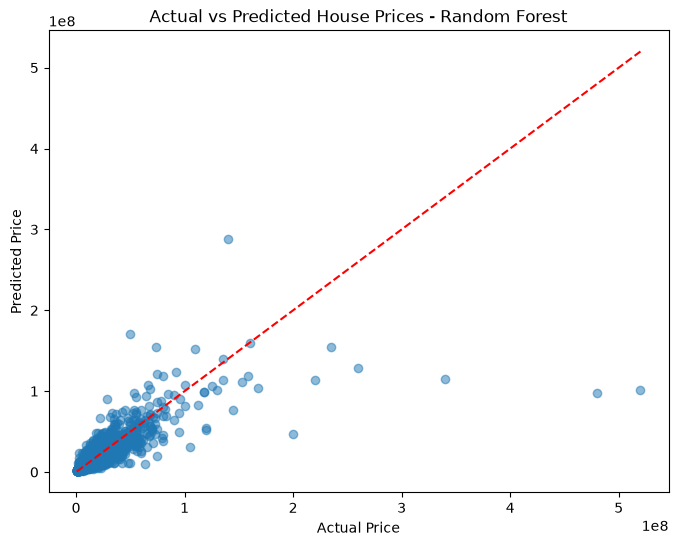

In [128]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices - Random Forest")

plt.show()

In [129]:
#The scatter plot shows the relationship between the actual and predicted house prices using the Random Forest model. Most predictions follow the general trend of the actual prices, although some high-priced properties have larger prediction errors. Overall, the model provides reasonable predictions and performed better than the other models based on the MAE, RMSE, and R² evaluation metrics.

In [130]:
import joblib

joblib.dump(random_forest_model, "house_price.pkl")

print("Model saved successfully!")

Model saved successfully!


In [131]:
# Reload the saved model
loaded = joblib.load("house_price.pkl")

# Select one sample from the test set
sample = X_test.iloc[[0]]

# Make a prediction
print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [15872000.]


In [132]:
import json

locations = sorted(
    df["location_clean"].unique().tolist()
)

with open("locations.json", "w") as file:
    json.dump(locations, file)

print("Locations saved successfully!")


Locations saved successfully!


In [133]:
import sklearn
print(sklearn.__version__)

1.9.0
